<a href="https://colab.research.google.com/github/DharshiniSoundappan/ML-loan-approval/blob/main/ML_Classification_Loan_Approval.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎯 ML Classification Demo – End‑to‑End Example

covering:
- Business use case
- Null imputation
- Encoding
- Bivariate analysis
- Train–test split
- Model training & evaluation

## 📌 Use Case: Customer Loan Approval Prediction

**Problem:** Predict whether a customer’s loan will be **Approved (1)** or **Rejected (0)** based on demographic & financial features.

**Why interesting?**
- Real business relevance (banking/fintech)
- Contains missing values
- Mix of numerical & categorical features
- Perfect for explaining ML pipeline

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## 📂 Step 1: Create Sample Dataset (with NULLs)

In [ ]:
df = pd.read_csv("/content/sample_data/loan_approval_1000.csv")

In [ ]:
len(df)

1000

In [ ]:
df

,Age,Income,Loan_Amount,Credit_Score,Employment_Type,Loan_Approved
0,59,77761.0,417505,337,Salaried,0
1,49,141178.0,328226,487,Salaried,0
2,35,56368.0,312805,356,Self-Employed,0
3,28,26783.0,218484,319,Salaried,0
4,41,131530.0,315064,572,Self-Employed,0
...,...,...,...,...,...,...
995,58,112447.0,259717,572,Unemployed,0
996,22,134994.0,314167,544,Unemployed,0
997,27,109899.0,169654,749,Salaried,1
998,38,40049.0,240868,546,Unemployed,0


## 🔍 Step 2: Null Value Analysis

In [ ]:

df.isnull().sum()


,0
Age,0
Income,50
Loan_Amount,0
Credit_Score,0
Employment_Type,50
Loan_Approved,0


## 🧹 Step 3: Null Imputation
- Numerical → Median
- Categorical → Mode

In [ ]:

df["Income"].fillna(df["Income"].median(), inplace=True)
df["Employment_Type"].fillna(df["Employment_Type"].mode()[0], inplace=True)

df.isnull().sum()


/tmp/ipykernel_901/130035395.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Income"].fillna(df["Income"].median(), inplace=True)
/tmp/ipykernel_901/130035395.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', 

,0
Age,0
Income,0
Loan_Amount,0
Credit_Score,0
Employment_Type,0
Loan_Approved,0


## 🔠 Step 4: Encoding Categorical Data

In [ ]:

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df["Employment_Type"] = le.fit_transform(df["Employment_Type"])

df.head()


,Age,Income,Loan_Amount,Credit_Score,Employment_Type,Loan_Approved
0,59,77761.0,417505,337,0,0
1,49,141178.0,328226,487,0,0
2,35,56368.0,312805,356,1,0
3,28,26783.0,218484,319,0,0
4,41,131530.0,315064,572,1,0


## 🧪 Step 5: Train–Test Split

In [ ]:

from sklearn.model_selection import train_test_split

X = df.drop("Loan_Approved", axis=1)
y = df["Loan_Approved"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train.shape, X_test.shape


((800, 5), (200, 5))

## 🤖 Step 6: Model Training (Logistic Regression)

In [ ]:

from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)


LogisticRegression(max_iter=1000)

## 📈 Step 7: Model Evaluation

In [ ]:

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.79

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.87      0.85       135
           1       0.70      0.62      0.66        65

    accuracy                           0.79       200
   macro avg       0.76      0.74      0.75       200
weighted avg       0.79      0.79      0.79       200



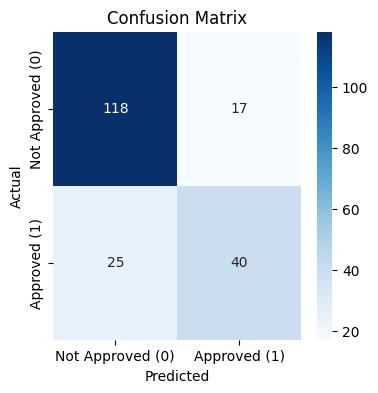

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(4,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Approved (0)", "Approved (1)"],
    yticklabels=["Not Approved (0)", "Approved (1)"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()